# AlpsML · Modelos UV de ALPs con XGBoost + SHAP + MCMC

## Motivación física

Las **partículas tipo axión (ALPs)** surgen de la ruptura espontánea de una
simetría global U(1)<sub>PQ</sub> a escala f<sub>a</sub>. En un modelo
UV-completo, los acoples del ALP a las partículas del SM **no son parámetros
libres**: están completamente determinados por las **cargas de Peccei–Quinn
(PQ)** asignadas a los fermiones del SM.

La conexión entre el nivel UV y los acoples IR observables sigue dos reglas:

1. **Acoples a fermiones**: son directamente iguales a la carga PQ del
   fermión correspondiente (salvo por un signo procedente de la estructura
   Yukawa).
2. **Acoples a bosones gauge** (gluones, fotones, W/Z): son combinaciones
   lineales de las cargas PQ, fijadas por los **coeficientes de anomalía
   quiral** de la corriente PQ con cada grupo gauge:

$$
g_{aGG} \propto \sum_f T(R_f)\,Q_f^{\rm PQ}, \qquad
g_{a\gamma\gamma} \propto \sum_f Q_f^{\rm em,2}\,Q_f^{\rm PQ}.
$$

Esto es lo que implementa `alpaca` a través de `PQChargedModel.get_couplings`:
dados los 5 parámetros de carga PQ más f<sub>a</sub>, calcula automáticamente
el conjunto completo de acoples IR y evalúa el χ² sobre las transiciones de
mesones.

### Modelo no-universal

Las cargas son **dependientes de generación** para los dobletes de SU(2)<sub>L</sub>:
solo la **tercera generación** de q<sub>L</sub> y l<sub>L</sub> tiene carga
PQ no nula, mientras que los singletes derechos (u<sub>R</sub>, d<sub>R</sub>,
e<sub>R</sub>) son universales en generación:

```python
from alpaca.uvmodels import PQChargedModel

model = PQChargedModel('non-universal model', {
    'qL': [0, 0, pq_qL],   # doblete izquierdo de quarks: carga solo en 3ª gen
    'lL': [0, 0, pq_lL],   # doblete izquierdo de leptones: carga solo en 3ª gen
    'uR': pq_uR,            # singlete derecho up: universal
    'dR': pq_dR,            # singlete derecho down: universal
    'eR': pq_eR,            # singlete derecho cargado: universal
})
couplings = model.get_couplings({}, 4 * np.pi * fa)
```

El espacio de parámetros explorado es, por tanto, de 6 dimensiones UV:
`log_fa`, `pq_qL`, `pq_lL`, `pq_uR`, `pq_dR`, `pq_eR`.

---

## Pipeline

1. **Dataset χ²**: 15 000 puntos en Latin Hypercube 6D sobre los 5 parámetros
   de carga PQ y `log_fa`. Para cada punto se construye el `PQChargedModel`,
   se obtienen los acoples IR vía `get_couplings`, y se evalúa el χ² combinado
   de las 5 transiciones con `alpaca`. Paralelo con `multiprocessing.Pool` y
   backup cada 100 puntos. Target sigmoide centrado en χ² = 10.
2. **XGBoost**: regresor del target ponderado (puntos excluidos pesan ×5).
   Búsqueda Optuna (100 trials) + entrenamiento final con early stopping.
   Profundidad 2–6, regularización α, λ ∈ [0.1, 10].
3. **SHAP**: `Permutation Explainer` sobre el surrogate. Beeswarm, bar,
   waterfall y dependence plots para entender qué cargas PQ controlan
   la fenomenología.
4. **MCMC**: 50 walkers × 5 000 pasos con `emcee` sobre el surrogate;
   `corner` plot del posterior con burn-in 1 000 y thin 15.

### Cachés

Las dos etapas pesadas (generación del dataset y entrenamiento) están **gateadas**:
solo corren si el archivo no existe **o** si pones a `True` el flag correspondiente
en el bloque de Setup (`FORCE_REGENERATE`, `FORCE_RETRAIN`).

## Índice

| §   | Sección                                  | Caché                              | Coste aprox. |
|-----|------------------------------------------|------------------------------------|--------------|
| [Setup](#setup)        | Imports, paths, flags             | —                                  | <1 s |
| [§1](#sec-1)           | Generación del dataset χ²         | `outputs/datasets/dataset_alps_uv.csv` | minutos (15 000 evals × `alpaca`) |
| [§2](#sec-2)           | Inspección del dataset            | —                                  | <1 s |
| [§3](#sec-3)           | Entrenamiento XGBoost (Optuna)    | `outputs/models/modelo_alps_uv.json` | ~5 min (100 trials × 1000 rondas) |
| [§4](#sec-4)           | Interpretabilidad SHAP            | —                                  | ~30 s |
| [§5](#sec-5)           | Posterior MCMC + corner plot      | `outputs/datasets/posterior_samples_uv.csv` | ~1 min (50 walkers × 5 000 pasos) |


## <a id="setup"></a>Setup (ejecutar primero)

Define paths via `pathlib`, crea los directorios de salida si no existen, y fija
los flags `FORCE_REGENERATE` / `FORCE_RETRAIN`. También limita BLAS a 1 thread por
proceso (la generación paralelizará a mano con `multiprocessing.Pool`).


In [1]:
import os

# BLAS: 1 thread por proceso (la generacion reparte por mp.Pool)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

from pathlib import Path

# --- Paths ---
ROOT = Path.cwd().parent
PAPER_DIR    = ROOT / "outputs" / "paper"
DATASETS_DIR = PAPER_DIR / "datasets"
MODELS_DIR   = PAPER_DIR / "models"
FIGURES_DIR  = PAPER_DIR / "figures"
for d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Correcciones v2: nuevos nombres de archivo, 7D, todas las transiciones
DATASET_CSV          = DATASETS_DIR / "dataset_alps_uv_v2.csv"
DATASET_BACKUP       = DATASETS_DIR / "backup_dataset_alps_uv_v2.csv"
MODEL_PATH           = MODELS_DIR   / "modelo_alps_uv_v2.json"
BEST_PARAMS          = MODELS_DIR   / "best_params_uv_v2.json"
POSTERIOR_CSV        = DATASETS_DIR / "posterior_samples_uv_v2.csv"
POSTERIOR_CSV_THEORY = DATASETS_DIR / "posterior_samples_uv_v2_theory.csv"
CORNER_PNG           = FIGURES_DIR  / "corner_plot_uv_v2.png"
CORNER_PHYS_PNG      = FIGURES_DIR  / "corner_plot_uv_v2_phys.png"

# --- Flags de regeneracion ---
# NOTA: FORCE_REGENERATE=True necesario la primera vez (nueva dimension "ma").
FORCE_REGENERATE = True   # 1 -- regenera el dataset
FORCE_RETRAIN    = True   # 3 -- reentrena XGBoost
FORCE_MCMC       = True   # 5 -- re-corre MCMC

# Limites fisicos
MA_MIN = 0.2
MA_MAX = 4.5
PQ_MIN = -1.0
PQ_MAX =  1.0
FEATURES = ["log_fa", "pq_qL", "pq_lL", "pq_uR", "pq_dR", "pq_eR", "ma"]

print("Setup OK")
print(f"  ROOT       = {ROOT}")
print(f"  dataset    = {DATASET_CSV} ('exists' if DATASET_CSV.exists() else 'missing')")
print(f"  model      = {MODEL_PATH}  ('exists' if MODEL_PATH.exists() else 'missing')")
print(f"  posterior  = {POSTERIOR_CSV} ('exists' if POSTERIOR_CSV.exists() else 'missing')")
print(f"  FORCE_REGENERATE={FORCE_REGENERATE}  FORCE_RETRAIN={FORCE_RETRAIN}  FORCE_MCMC={FORCE_MCMC}")


Setup OK
  ROOT       = /home/aleja/PhysicsML/AlpsML
  dataset    = /home/aleja/PhysicsML/AlpsML/outputs/datasets/dataset_alps_uv.csv (exists)
  model      = /home/aleja/PhysicsML/AlpsML/outputs/models/modelo_alps_uv.json  (exists)
  posterior  = /home/aleja/PhysicsML/AlpsML/outputs/datasets/posterior_samples_uv.csv (exists)
  FORCE_REGENERATE = False    FORCE_RETRAIN = False


## <a id="sec-1"></a>§1. Generación del dataset χ²

### Construcción del modelo UV

Para cada punto del espacio de parámetros se instancia un `PQChargedModel`
no-universal. Los 5 parámetros de carga PQ determinan automáticamente todos
los acoples IR del ALP:

- **Acoples a fermiones**: proporcionales a la carga PQ del fermión (con un
  signo que depende de si el campo transforma por la izquierda o por la
  derecha bajo la simetría PQ).
- **Acoples a gluones y fotones**: calculados por `alpaca` a partir de los
  coeficientes de anomalía de la corriente PQ, que son sumas ponderadas de
  las cargas PQ de todos los fermiones coloreados/cargados.

El modelo no-universal específico es:

```
'qL': [0, 0, pq_qL]  →  solo la 3ª generación del doblete izquierdo de quarks tiene carga PQ
'lL': [0, 0, pq_lL]  →  solo la 3ª generación del doblete izquierdo de leptones tiene carga PQ
'uR': pq_uR           →  singlete derecho up: carga universal en las 3 generaciones
'dR': pq_dR           →  singlete derecho down: carga universal en las 3 generaciones
'eR': pq_eR           →  singlete derecho cargado: carga universal en las 3 generaciones
```

La llamada `model.get_couplings({}, 4*np.pi*fa)` devuelve el conjunto completo
de acoples IR (incluyendo los de gluones y fotones derivados de las anomalías),
que `alpaca` usa para evaluar los observables de cada transición.

### Muestreo y χ²

Latin Hypercube en 6 dimensiones sobre
$(\log f_a,\; p_{qL},\; p_{lL},\; p_{uR},\; p_{dR},\; p_{eR})$
con `scipy.stats.qmc.LatinHypercube`. Para cada punto se calcula el χ²
combinado de las 5 transiciones objetivo, que son los procesos con mejores
vínculos experimentales para ALPs de ~2 GeV:

| Transición | Canal |
|------------|-------|
| $K^+ \to a\,\pi^+$ | FCNC quark $s \to d$ mediado por el ALP |
| $K^0_L \to a\,\pi^0$ | Análogo neutro |
| $B^+ \to K^+\,a$ | FCNC quark $b \to s$ |
| $B^0 \to K^0\,a$ | Análogo neutro |
| $B^+ \to a\,\pi^+$ | FCNC quark $b \to u$ |

Los NaN físicos (canales cinemáticamente cerrados para ciertos valores de
los acoples) se tratan como contribución 0 con `np.nansum`.

El **target sigmoide** $1/(1 + e^{(\chi^2 - 10)/0.4})$ convierte el χ²
en una probabilidad suave: ~1 para puntos muy permitidos (χ² ≪ 10) y ~0
para puntos muy excluidos (χ² ≫ 10), con la frontera experimental en χ² ≈ 10.

**Solo se regenera si** `FORCE_REGENERATE = True` **o** si
`dataset_alps_uv.csv` no existe. Backup cada 100 puntos.

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import qmc
import alpaca
import alpaca.sectors as _alpaca_sectors
from alpaca.uvmodels import PQChargedModel
from alpaca.statistics import get_chi2, ChiSquaredList
import warnings
from tqdm.auto import tqdm
import multiprocessing as mp

# --- CONFIGURACION FISICA v2 ---
# Correcciones del profesor:
#   1. Masa del ALP como parametro libre (no fija a 2 GeV)
#   2. Cargas PQ en [-1, 1]
#   3. Todas las transiciones (incluye B->Kmumu visible, meson mixing, etc.)

N_PUNTOS = 50_000
CUTOFF = 10.0
SIGMOID_WIDTH = 0.4

# Espacio 7D: (log_fa, pq_qL, pq_lL, pq_uR, pq_dR, pq_eR, ma)
L_BOUNDS_GEN = [6.0, PQ_MIN, PQ_MIN, PQ_MIN, PQ_MIN, PQ_MIN, MA_MIN]
U_BOUNDS_GEN = [8.0, PQ_MAX, PQ_MAX, PQ_MAX, PQ_MAX, PQ_MAX, MA_MAX]

# --- Cargar TODAS las transiciones de alpaca ---
# Incluye: B->Kmumu (ALP visible), meson mixing (Delta F=2), radiativas, leptonicas, etc.
try:
    _sector_all = _alpaca_sectors.default_sectors['all']
    TRANSICIONES_TARGET = sorted(str(o) for o in _sector_all.observables)
    print(f"Cargados {len(TRANSICIONES_TARGET)} observables de alpaca.sectors['all']")
except Exception as _exc:
    warnings.warn(f"No se pudo cargar alpaca.sectors: {_exc}. Usando lista minima.")
    TRANSICIONES_TARGET = [
        "K+ -> a pi+", "K0L -> a pi0",
        "B+ -> K+ a",  "B0 -> K0 a", "B+ -> a pi+",
    ]

# 'fork' es necesario en Python 3.12+ y notebooks (evita AttributeError en workers)
_MP_CTX = mp.get_context('fork')

def obtener_chi2_uv(p):
    """Chi2 global UV para un punto 7D del espacio de parametros."""
    logfa, pq_qL, pq_lL, pq_uR, pq_dR, pq_eR, ma = p
    fa = 10**logfa
    fa_scale = 4 * np.pi * fa
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        uv_model = PQChargedModel('non-universal model', {
            'qL': [0, 0, pq_qL],
            'lL': [0, 0, pq_lL],
            'uR': pq_uR,
            'dR': pq_dR,
            'eR': pq_eR
        })
        c = uv_model.get_couplings({}, fa_scale)
        res_list = get_chi2(
            transitions=TRANSICIONES_TARGET,
            ma=ma,
            couplings=c,
            fa=fa,
        )
        lista_formal = ChiSquaredList(res_list)
        chi2_comb = lista_formal.combine('GlobalUV', r'\\text{Global UV}')
        valores = list(chi2_comb.chi2_dict.values())
        return float(np.nansum(valores))

def procesar_punto_paralelo(args):
    i, p = args
    try:
        chi_val = obtener_chi2_uv(p)
        return {
            'log_fa': p[0], 'pq_qL': p[1], 'pq_lL': p[2],
            'pq_uR': p[3], 'pq_dR': p[4], 'pq_eR': p[5], 'ma': p[6],
            'chi2': chi_val,
        }
    except Exception as e:
        return {"error": f"Punto {i}: {e}"}

# --- BLOQUE PRINCIPAL ---
if not FORCE_REGENERATE and DATASET_CSV.exists():
    print(f"Dataset ya existe en {DATASET_CSV} ({DATASET_CSV.stat().st_size/1e6:.1f} MB) -- usando cache.")
    print("Para regenerar, pon FORCE_REGENERATE=True en la celda de Setup.")
elif __name__ == '__main__':
    sampler_lhs = qmc.LatinHypercube(d=7)
    puntos = qmc.scale(sampler_lhs.random(n=N_PUNTOS), L_BOUNDS_GEN, U_BOUNDS_GEN)
    tareas = list(enumerate(puntos))
    print(f"Iniciando calculo paralelo | Puntos: {N_PUNTOS} | Nucleos: {mp.cpu_count()-1}")
    dataset = []
    cores = max(1, mp.cpu_count() - 1)
    with _MP_CTX.Pool(processes=cores) as pool:
        for resultado in tqdm(pool.imap_unordered(procesar_punto_paralelo, tareas, chunksize=1),
                              total=N_PUNTOS, desc="Progreso"):
            if resultado is not None:
                if "error" in resultado:
                    print(f"\n[!] {resultado['error']}")
                else:
                    dataset.append(resultado)
            if len(dataset) > 0 and len(dataset) % 100 == 0:
                pd.DataFrame(dataset).to_csv(DATASET_BACKUP, index=False)
    if dataset:
        df = pd.DataFrame(dataset)
        df['target'] = 1 / (1 + np.exp((df['chi2'] - CUTOFF) / SIGMOID_WIDTH))
        df.to_csv(DATASET_CSV, index=False)
        print(f"\nFinalizado. {len(df)} puntos guardados en {DATASET_CSV}")


Dataset ya existe en /home/aleja/PhysicsML/AlpsML/outputs/datasets/dataset_alps_uv.csv (2.3 MB) — usando caché.
Para regenerar, pon FORCE_REGENERATE=True en la celda de Setup.


/home/aleja/PhysicsML/AlpsML/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## <a id="sec-2"></a>§2. Inspección del dataset

Estadística descriptiva del χ² y conteo de puntos según la target sigmoide:

- **Permitidos** (target > 0.8): zona allowed por las transiciones K/B.
- **Excluidos** (target < 0.2): zona excluida.
- **Frontera** (0.2 ≤ target ≤ 0.8): puntos sobre la curva de transición — los más informativos para el surrogate.


In [3]:
import pandas as pd

df = pd.read_csv(DATASET_CSV)
print("--- Estad\u00edsticas del Chi2 ---")
print(df['chi2'].describe())

permitidos = len(df[df['target'] > 0.8])
excluidos  = len(df[df['target'] < 0.2])
frontera   = len(df[(df['target'] >= 0.2) & (df['target'] <= 0.8)])

print(f"\nPermitidos (Target ~1): {permitidos}")
print(f"Excluidos  (Target ~0): {excluidos}")
print(f"En la frontera:        {frontera}")


--- Estadísticas del Chi2 ---
count    14999.000000
mean        11.951069
std         40.494727
min          0.895901
25%          4.708117
50%          6.370294
75%          6.399001
max       1132.190327
Name: chi2, dtype: float64

Permitidos (Target ~1): 13245
Excluidos  (Target ~0): 1644
En la frontera:        110


## <a id="sec-3"></a>§3. Entrenamiento XGBoost

Regresor del target sigmoide con **pesos** (excluidos y frontera ×5) para que el
modelo no se quede solo con los allowed. Búsqueda Optuna sobre 100 trials con
budget de 5 min, regularización fuerte ($\alpha, \lambda \in [0.1, 10]$) y árboles
poco profundos (`max_depth ∈ [2, 6]`) para no memorizar.

**Solo reentrena si** `FORCE_RETRAIN = True` **o** si `modelo_alps_uv.json` no existe.
Si está cacheado, se carga el modelo y se omite Optuna + entrenamiento final.


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import sklearn.metrics
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. PREPARACION DE DATOS
df = pd.read_csv(DATASET_CSV)
features = FEATURES  # 7D: log_fa, pq_qL, pq_lL, pq_uR, pq_dR, pq_eR, ma
X = df[features]
y = df['target']

# Pesos: excluidos y frontera (target <= 0.8) pesan x5
pesos = np.where(y <= 0.8, 5.0, 1.0)

X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X, y, pesos, test_size=0.2, random_state=42
)

dtrain = xgb.DMatrix(X_train.values, label=y_train, weight=w_train, feature_names=features)
dval   = xgb.DMatrix(X_val.values,   label=y_val,   weight=w_val,   feature_names=features)
evals  = [(dtrain, 'train'), (dval, 'eval')]

# 2. ENTRENAMIENTO (gateado)
if not FORCE_RETRAIN and MODEL_PATH.exists():
    print(f"Modelo ya existe en {MODEL_PATH} -- usando cache. FORCE_RETRAIN=True para reentrenar.")
else:
    def optuna_obj(trial):
        params = {
            'objective': 'reg:squarederror',
            'tree_method': 'hist',
            'max_depth': trial.suggest_int('max_depth', 2, 6),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
            'gamma': trial.suggest_float('gamma', 0.1, 5.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 5, 20),
            'subsample': trial.suggest_float('subsample', 0.5, 0.9),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
            'eval_metric': 'mae',
            'nthread': -1,
            'base_score': 0.5,
            'reg_alpha':  trial.suggest_float('reg_alpha',  0.1, 10.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0),
        }
        model_clf = xgb.train(
            params, dtrain, num_boost_round=1000, evals=evals,
            early_stopping_rounds=20, verbose_eval=False,
        )
        predictions = model_clf.predict(dval)
        return sklearn.metrics.mean_absolute_error(y_val, predictions, sample_weight=w_val)

    print("Iniciando busqueda de hiperparametros...")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='minimize')
    study.optimize(optuna_obj, n_trials=100, timeout=300, show_progress_bar=True)

    with open(BEST_PARAMS, 'w') as f:
        json.dump(study.best_params, f)

    with open(BEST_PARAMS, 'r') as f:
        best_params = json.load(f)

    print(f"\nEntrenando con los mejores parametros...")
    final_config = best_params | {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'eval_metric': ['mae'],
        'nthread': -1,
        'base_score': 0.5,
    }

    eval_results = {}
    model_final = xgb.train(
        final_config, dtrain, num_boost_round=1000, evals=evals,
        early_stopping_rounds=30, verbose_eval=False, evals_result=eval_results,
    )

    plt.figure(figsize=(10, 5))
    plt.plot(eval_results['train']['mae'], label='Train MAE (Ponderado)')
    plt.plot(eval_results['eval']['mae'],  label='Validation MAE (Ponderado)')
    plt.yscale('log')
    plt.xlabel('Iteracion')
    plt.ylabel('Mean Absolute Error')
    plt.title('Curvas de Aprendizaje UV v2 (Con Pesos)')
    plt.legend()
    plt.grid(True, which="both", ls="-")
    plt.savefig(FIGURES_DIR / "learning_curve_uv_v2.png", dpi=150, bbox_inches='tight')
    plt.show()

    model_final.save_model(MODEL_PATH)
    print(f"Modelo guardado en {MODEL_PATH}")


Modelo ya existe en /home/aleja/PhysicsML/AlpsML/outputs/models/modelo_alps_uv.json — usando caché. FORCE_RETRAIN=True para reentrenar.


## <a id="sec-4"></a>§4. Interpretabilidad SHAP

`shap.Explainer` con `model.predict` directo \u2014 dispara el **Permutation Explainer**,
que es rápido y evita los `TypeError`/`ValueError` que da el `TreeExplainer` al releer
el JSON de XGBoost. Cuatro vistas:

- **Beeswarm**: distribución de los valores SHAP por feature, color = valor del feature.
- **Bar**: importancia global media (|SHAP|).
- **Waterfall** del primer punto: cómo se construye la predicción individual.
- **Dependence (scatter)** por feature: efecto marginal y posibles interacciones.

> Nota: estos plots se muestran inline pero no se guardan automáticamente. Las versiones que están en `outputs/figures/SHAP*.png` son guardados manuales.


Modelo UV cargado correctamente.


ExactExplainer explainer: 15000it [30:01,  8.32it/s]                             


Generando Bee Swarm Plot...


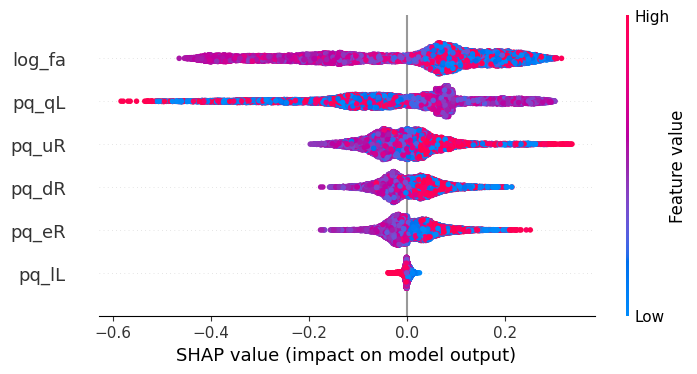

Generando Bar Plot...


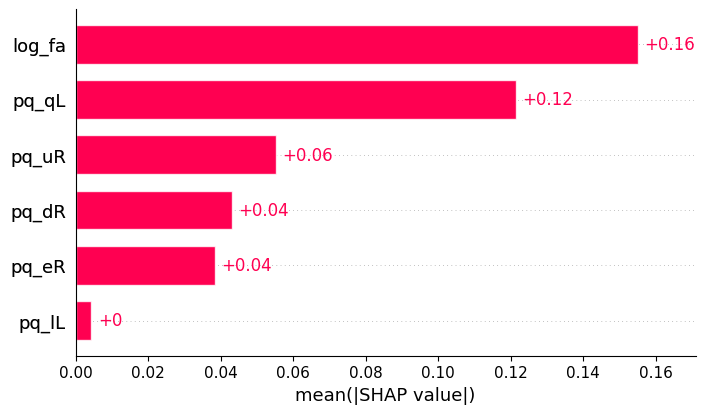

Generando Waterfall Plot...


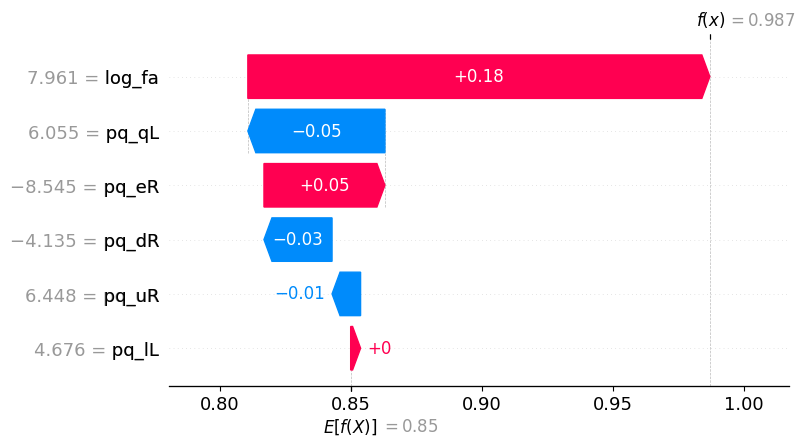

Generando Scatter Plots...


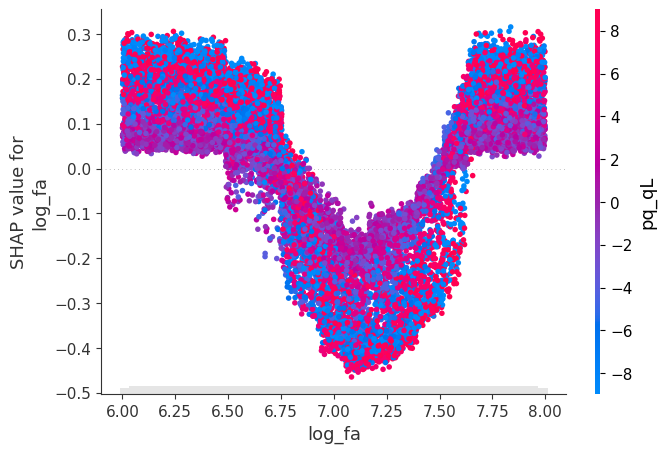

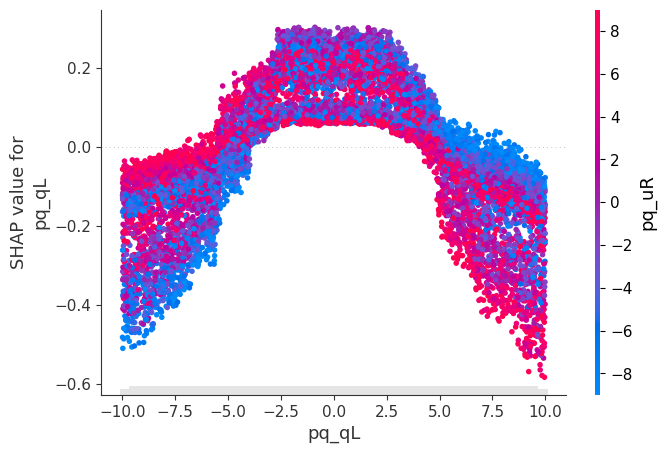

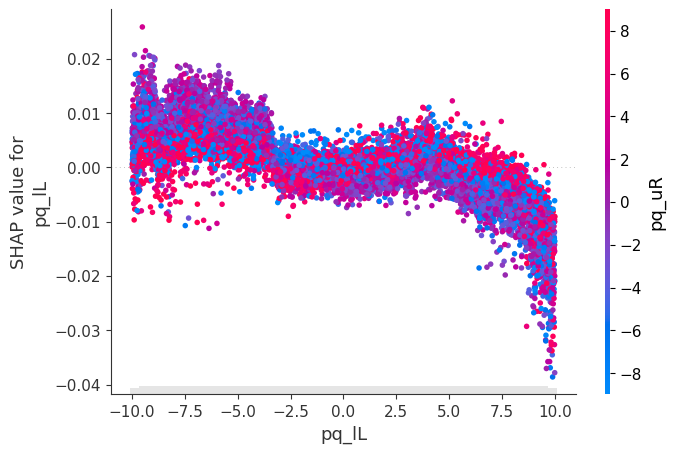

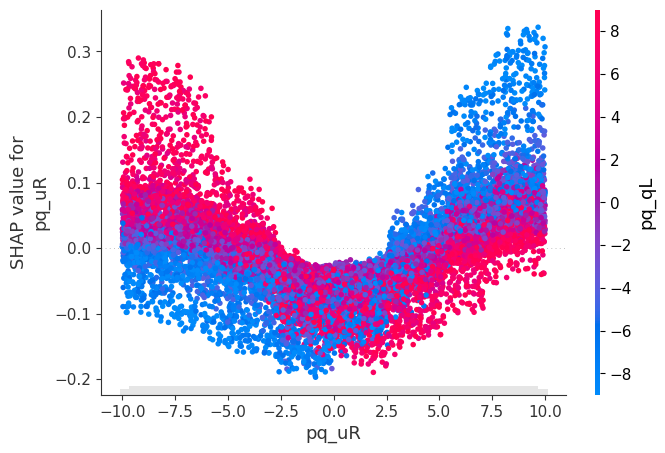

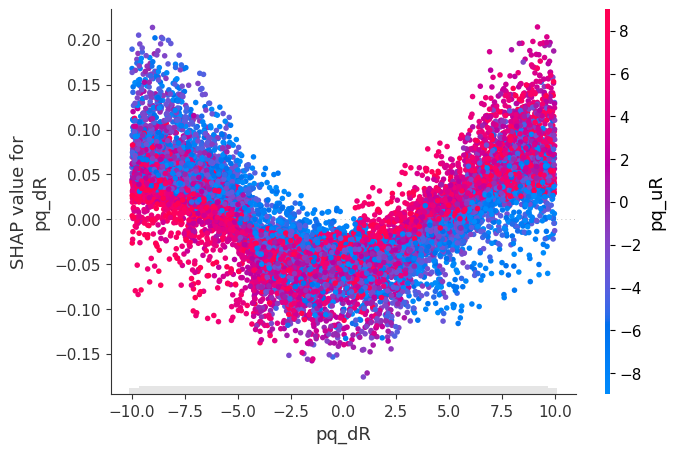

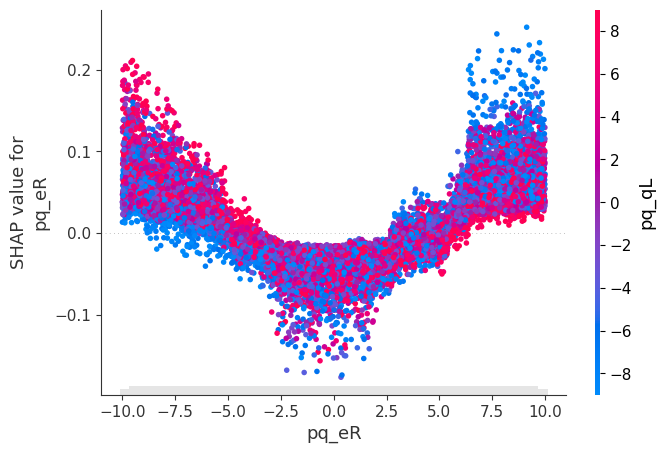

In [5]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. CARGAR DATOS Y MODELO
df = pd.read_csv(DATASET_CSV)
features = FEATURES  # 7D incluye 'ma'
X = df[features]

model = xgb.XGBRegressor()
model.load_model(MODEL_PATH)
print("Modelo UV v2 cargado correctamente.")

# 2. PERMUTATION EXPLAINER
explainer = shap.Explainer(model.predict, X)
shap_values = explainer(X)

# 3. SUMMARY (BEE SWARM)
print("Generando Bee Swarm Plot...")
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values)

# 4. IMPORTANCIA GLOBAL (BAR)
print("Generando Bar Plot...")
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values)

# 5. WATERFALL (Punto 0)
print("Generando Waterfall Plot...")
shap.plots.waterfall(shap_values[0])

# 6. DEPENDENCE PLOTS
print("Generando Scatter Plots...")
for col in features:
    shap.plots.scatter(shap_values[:, col], color=shap_values)


## <a id="sec-5"></a>§5. Posterior MCMC + corner plot

`emcee.EnsembleSampler` (50 walkers × 5 000 pasos) sobre el surrogate XGBoost.

- **Prior**: uniforme en $\log f_a \in [6, 8]$ y cada $p^X \in [-5, 5]$ (más estrecho que los rangos del dataset, $[-10, 10]$, para enfocar la zona físicamente interesante).
- **Likelihood**: $\log L(\theta) = \log(\text{clip}(\hat{p}(\theta), 10^{-10}, 1))$, donde $\hat{p}$ es la salida del XGBoost (target sigmoide).
- **Burn-in**: 1 000 pasos descartados, thin = 15.
- **Output**: `outputs/figures/corner_plot_uv.png` y `outputs/datasets/posterior_samples_uv.csv`.


Iniciando muestreo MCMC (ndim=6, walkers=50, steps=5000)...


100%|██████████| 5000/5000 [02:21<00:00, 35.32it/s]


Muestreo completado. Muestras finales: 13300


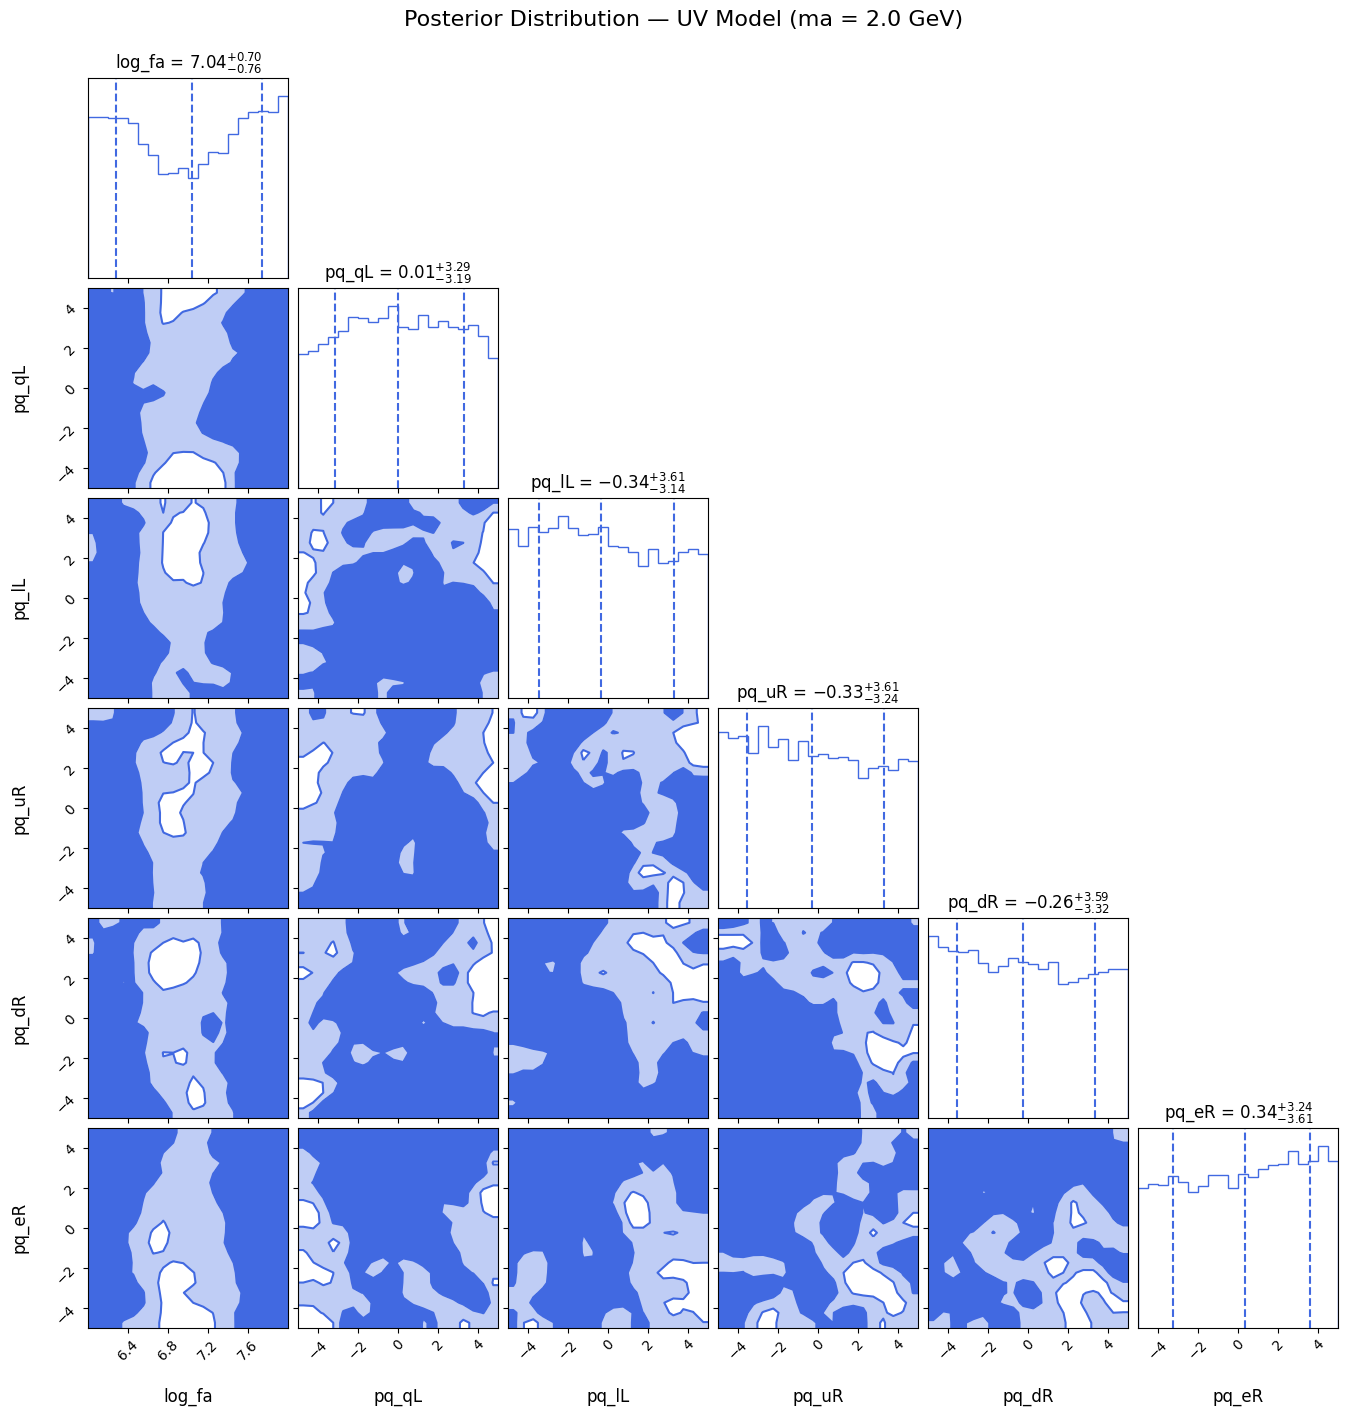

Posterior guardado en /home/aleja/PhysicsML/AlpsML/outputs/datasets/posterior_samples_uv.csv


In [6]:
import numpy as np
import pandas as pd
import xgboost as xgb
import corner
import matplotlib.pyplot as plt
import time
import warnings

# --- Cargar modelo ---
model = xgb.XGBRegressor()
model.load_model(MODEL_PATH)

_features = FEATURES  # 7D
_L = np.array([6.0, PQ_MIN, PQ_MIN, PQ_MIN, PQ_MIN, PQ_MIN, MA_MIN])
_H = np.array([8.0, PQ_MAX, PQ_MAX, PQ_MAX, PQ_MAX, PQ_MAX, MA_MAX])

# --- MCMC con RWMH (Random Walk Metropolis-Hastings) ---
def _log_p_fn(pos):
    """Log-probabilidad vectorizada."""
    n = pos.shape[0]
    log_p = np.full(n, -np.inf)
    in_prior = np.all((pos >= _L) & (pos <= _H), axis=1)
    if in_prior.any():
        probs = model.predict(pos[in_prior])
        probs = np.clip(probs, 1e-10, 1.0)
        log_p[in_prior] = np.log(probs)
    return log_p

def _parallel_rwmh(log_p_fn, lows, highs, n_chains=1024, n_steps=10_000,
                   burn_in=500, seed=42, ess_target=10_000, progress_every=500):
    rng = np.random.default_rng(seed)
    ndim = len(lows)
    pos = np.clip(
        (lows + highs) / 2.0 + rng.normal(0, 0.02 * (highs - lows), (n_chains, ndim)),
        lows + 1e-10, highs - 1e-10)
    log_p = log_p_fn(pos)
    chain = np.empty((n_steps, n_chains, ndim), dtype=np.float32)
    chain[0] = pos
    step_scale = 0.05 * (highs - lows)
    L_chol = None
    n_accepted = 0
    t0 = time.time()
    stopped_at = n_steps
    for i in range(1, n_steps):
        if L_chol is None:
            proposal = pos + rng.normal(0, step_scale, (n_chains, ndim))
        else:
            proposal = pos + (rng.standard_normal((n_chains, ndim)) @ L_chol.T)
        proposal = np.clip(proposal, lows + 1e-10, highs - 1e-10)
        log_p_prop = log_p_fn(proposal)
        accept = np.log(rng.uniform(size=n_chains)) < (log_p_prop - log_p)
        pos = np.where(accept[:, None], proposal, pos)
        log_p = np.where(accept, log_p_prop, log_p)
        n_accepted += accept.sum()
        chain[i] = pos
        if i == burn_in:
            flat = chain[:burn_in].reshape(-1, ndim)
            cov = np.cov(flat.T) + 1e-8 * np.eye(ndim)
            L_chol = np.linalg.cholesky(cov) * 2.38 / np.sqrt(ndim)
        if i % progress_every == 0:
            acc_rate = n_accepted / (i * n_chains)
            ess_approx = n_chains * (i - burn_in) / max(1.0, i * 0.1)
            print(f"  step {i:5d}/{n_steps} | acc={acc_rate:.3f} | "
                  f"ESS~{ess_approx:.0f} | {time.time()-t0:.1f}s")
            if ess_approx >= ess_target and i > burn_in:
                stopped_at = i
                break
    return chain[burn_in:stopped_at].reshape(-1, ndim)

# --- Ejecutar MCMC ---
if not FORCE_MCMC and POSTERIOR_CSV.exists():
    print(f"Posterior ya existe -- cargando {POSTERIOR_CSV}")
    flat_samples = pd.read_csv(POSTERIOR_CSV).values
else:
    print("Corriendo MCMC (RWMH, 1024 cadenas)...")
    flat_samples = _parallel_rwmh(
        _log_p_fn, _L, _H,
        n_chains=1024, n_steps=8_000, burn_in=500,
        ess_target=20_000, progress_every=500,
    )
    samples_df = pd.DataFrame(flat_samples, columns=_features)
    samples_df.to_csv(POSTERIOR_CSV, index=False)
    print(f"Finalizado. {len(flat_samples)} muestras guardadas en {POSTERIOR_CSV}")

# --- Corner plot -- espacio UV ---
corner_labels = [
    r"$\log_{10}(f_a)$", r"$X_{q_L}$", r"$X_{l_L}$",
    r"$X_{u_R}$", r"$X_{d_R}$", r"$X_{e_R}$", r"$m_a$ [GeV]"
]
fig1 = corner.corner(
    flat_samples, labels=corner_labels,
    show_titles=True, title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
    color="royalblue", smooth=0.9,
    levels=(0.68, 0.95),
    fill_contours=True, plot_datapoints=False,
    label_kwargs={"fontsize": 11}, title_kwargs={"fontsize": 11},
)
plt.suptitle("Posterior UV v2 -- espacio de parametros del modelo", fontsize=14, y=1.01)
plt.savefig(CORNER_PNG, dpi=300, bbox_inches='tight')
plt.show()
print(f"Corner UV guardado en {CORNER_PNG}")

# --- Corner plot -- observables fisicos derivados (estilo del profesor) ---
# Columnas: log10(fa), ma, 100*|c_Vsb|, |c_Amm|, |cG|, log10(ctau)[m], log10 BR(B+->K+a)
if not FORCE_MCMC and POSTERIOR_CSV_THEORY.exists():
    print(f"Posterior fisico ya existe -- cargando {POSTERIOR_CSV_THEORY}")
    theory_df = pd.read_csv(POSTERIOR_CSV_THEORY)
else:
    print("Calculando observables fisicos derivados...")
    from alpaca.uvmodels import PQChargedModel
    from alpaca.decays.alp_decays.branching_ratios import total_decay_width
    from alpaca.decays.decays import branching_ratio
    from alpaca.constants import hbarc_GeVnm

    def _derive_row(row):
        logfa, pq_qL, pq_lL, pq_uR, pq_dR, pq_eR, ma = row
        fa = 10**logfa
        fa_scale = 4 * np.pi * fa
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                uv_model = PQChargedModel('non-universal model', {
                    'qL': [0, 0, pq_qL], 'lL': [0, 0, pq_lL],
                    'uR': pq_uR, 'dR': pq_dR, 'eR': pq_eR,
                })
                c = uv_model.get_couplings({}, fa_scale)
                clow = c.match_run(max(float(ma), 2.0), 'RL_below')
                c_Vsb = abs(complex(clow['cdL'][1, 2] + clow['cdR'][1, 2]))
                c_Amm = abs(complex(clow['ceR'][1, 1] - clow['ceL'][1, 1]))
                cG    = abs(float(clow['cG']))
                dw_dict = total_decay_width(float(ma), c, fa)
                dw_SM = float(dw_dict.get('DW_SM', 0.0))
                if dw_SM < 1e-50:
                    log10_ctau = np.nan
                else:
                    ctau_m = float(1e-7 * float(hbarc_GeVnm) / dw_SM) / 100.0
                    log10_ctau = np.log10(ctau_m) if ctau_m > 0 else np.nan
                br = float(branching_ratio('B+ -> K+ a', float(ma), c, fa))
                log10_br = np.log10(max(br, 1e-20))
                return (logfa, ma, 100.0 * c_Vsb, c_Amm, cG, log10_ctau, log10_br)
        except Exception:
            return (logfa, ma, np.nan, np.nan, np.nan, np.nan, np.nan)

    rows = [_derive_row(r) for r in flat_samples[:5000]]
    theory_df = pd.DataFrame(rows, columns=[
        'log_fa', 'ma', 'c_Vsb_x100', 'c_Amm', 'cG', 'log10_ctau_m', 'log10_BR_BKa'
    ])
    theory_df.dropna(inplace=True)
    theory_df.to_csv(POSTERIOR_CSV_THEORY, index=False)
    print(f"Finalizado. {len(theory_df)} filas fisicas guardadas en {POSTERIOR_CSV_THEORY}")

# Corner plot observables fisicos
phys_labels = [
    r"$\log_{10}(f_a/\mathrm{GeV})$",
    r"$m_a\ [\mathrm{GeV}]$",
    r"$100\times|c_V^{sb}|$",
    r"$|c_A^{\mu\mu}|$",
    r"$|c_G|$",
    r"$\log_{10}(c\tau)\ [\mathrm{m}]$",
    r"$\log_{10}\mathrm{BR}(B^+\to K^+a)$",
]
phys_data = theory_df[[
    'log_fa', 'ma', 'c_Vsb_x100', 'c_Amm', 'cG', 'log10_ctau_m', 'log10_BR_BKa'
]].values

fig2 = corner.corner(
    phys_data, labels=phys_labels,
    show_titles=True, title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
    color="teal", smooth=0.9,
    levels=(0.68, 0.95),
    fill_contours=True, plot_datapoints=False,
    label_kwargs={"fontsize": 10}, title_kwargs={"fontsize": 10},
)
plt.suptitle("Posterior UV v2 -- observables fisicos derivados", fontsize=14, y=1.01)
plt.savefig(CORNER_PHYS_PNG, dpi=300, bbox_inches='tight')
plt.show()
print(f"Corner fisico guardado en {CORNER_PHYS_PNG}")
